## Bootstrapping Krippendorff's  $\alpha$

Based on [Krippendorff's bootstrapping algorthim.](https://www.asc.upenn.edu/sites/default/files/2021-03/Algorithm%20for%20Bootstrapping%20a%20Distribution%20of%20Alpha.pdf)
<br>

In order to estimate a confidence intervall for Krippendorff's $\alpha$, we need to find the distribution of $\alpha$. Krippendoff suggests doing this by bootstrapping distributions of $\alpha$, more specifically by resampling the reliability data. 

In Krippendorff's bootstrapping algorithm, hypothetical reliability data is sampled from the pairs of annotation categories which occur in the original data, ignoring the individual annotators. From this sampled reliability data a hypothetical observed disagreement, $D_o*$, is calculated. The expected disagreement, $D_e$ is considered more stable and is not sampled. The hypothetical alpha is then $1-D_o*/D_e$. Iterating this process will give us a probability distribution of $\alpha$, within the limits of $-1 \leq \alpha \leq 1 $.

Bootstrapping does not apply when $\alpha$ is 1.00 or the reliability data has no variance. <br>

For further reading: <br>
criticism: https://inter-rater-reliability.blogspot.com/2015/08/standard-error-of-krippendorffs-alpha.html <br>
bootstrapping in a different way: https://bmcmedresmethodol.biomedcentral.com/articles/10.1186/s12874-016-0200- <br>
discussion: https://stackoverflow.com/questions/32952366/bootstrapping-krippendorffs-alpha 


In [1]:
import random
import numpy
from collections import Counter
import matplotlib.pyplot as plt

###difference metrics for calculating alpha
def nominal_metric(a, b):
    return a != b

def interval_metric(a, b):
    return (a-b)**2

def ratio_metric(a, b):
    return ((a-b)/(a+b))**2


## Example Reliability Data

Below generates a simulated annotated dataset.

In [7]:
#Simulate annotations

def simulate_annotations(n_annotators=3, n_units=15, categories=('1','2','3','4'),
                         acc=0.75, miss_p=0.30, seed=42):
    
    """Returns a list of length n_annotators. Each element is a list of length n_units, 
    with entries in {'1','2','3','4','NA'} (strings).
    acc    = probability a non-missing coder gives the unit's true label
    miss_p = probability a coder's annotation is 'NA'
    """
    rng = random.Random(seed)

    # Sample hidden true label per unit
    true_labels = [rng.choice(categories) for _ in range(n_units)]

    all_annotators = []
    for _ in range(n_annotators):
        annotator = []
        for tl in true_labels:
            if rng.random() < miss_p:
                annotator.append('NA')
            else:
                if rng.random() < acc:
                    annotator.append(tl)  # correct label
                else:
                    # pick a wrong label (not tl)
                    other = [c for c in categories if c != tl]
                    annotator.append(rng.choice(other))
        all_annotators.append(annotator)

    return all_annotators

#print(annotations)

In [8]:
annotations = simulate_annotations(
    n_annotators=3, n_units=100, categories=('1','2','3','4'),
    acc=0.90, miss_p=0.1, seed=7
)

## Calculate observed $\alpha$ 

The code below calculates $\alpha$ based on the observed data. Based on this code: https://github.com/kb-labb/superlim-submissions/blob/main/scripts/kralpha.py
. <br>


In [9]:
#Turn data into coincidence matrix

#Units without annotation
maskitems = ['NA']

##Collect annotations per unit

units = {}   
for d in annotations:
    diter = enumerate(d)
    #for each annotation
    for it, g in diter:
        if g not in maskitems:
            units.setdefault(it,[]).append(float(g))

##Collect combinations of labels/values for calculating alpha
values = {}
for v in units.values():
   v = tuple(v)

   if len(v) < 2:
       pass
   elif v in values:
       values[v] += 1
   else:
       values[v] = 1


Below, alpha is calculated using the nominal metric. D_o and D_e are calculated and and finally alpha

In [10]:
metric = nominal_metric

#n..  , number of pairable values 
n = sum(len(v)*m for v,m in values.items())


Do = sum(m * sum(metric(gi,gj)
                 for gi in grades
                 for gj in grades) / (len(grades)-1)
         for grades,m in values.items()) / n

De = sum(m1 * m2 * metric(gi,gj)
         for grades1, m1 in values.items()
         for grades2, m2 in values.items()
         for gi in grades1
         for gj in grades2) / (n*(n-1))

observed_alpha = 1-(Do/De)
print('observed alpha: ',observed_alpha)

observed alpha:  0.7026369246100188


## Bootstrapping $\alpha$

In order to bootstrap $\alpha$, the number of unique pairs, $N_o$, that contribute to $\alpha$ is collected for sampling. 
Unique pairs refers not to the label combinations, but to the combination of annotations: in calculating $\alpha$ both the combination A-B and B-A (both from the perspective of annotator A and B) is used, but here only one combination is kept for sampling.

In [11]:
#Number of unique pairs that contribute to alpha
N_o = []
for v in units.values():
    v = tuple(v)
    if len(v) < 2:
       pass
    else:
        for i,annot1 in enumerate(v):
            for j,annot2 in enumerate(v):
                if i < j:
                    N_o.append((annot1,annot2))
        

#print(N_o)
print('Number of unique pairs that contribute to alpha:', len(N_o))


Number of unique pairs that contribute to alpha: 234


### Sampling annotation pairs 
From this list, $N_o$, annotation pairs are then sampled. This is done by for each unit calculating the number of unique pairs that occur in the original data for this unit, and for each of those pairs sample a new pair.

For each of the sampled pairs, their contribution to alpha is calculated and substracted. This is done in the E(r) function, defined by Krippendorff:

$E(r)= 2 * \frac{metric \delta^2_{ck}}{n.. * D_e}$

where:<br>
$metric\:\delta^2_{ck}$ = the difference function for the values c and k <br>
n.. = number of pairable values <br>
$D_e$ = Expected disagreement <br>

Krippendorff suggest sampling $\alpha$ 20000 times.  

Note that in Krippendorff's algorithm he refers to $E(r)$ and pairs as lists, and $N_o$ as a number - here the list $N_o$ represents all pairs in the reliability matrix to be sampled from, and the length of this list is the number of unique pairs.

In [12]:
def unique_pairs(m_u):
    return int(((m_u-1)*m_u)/2)

#### Bootstrapping algorithm

In [13]:
#Bootstrapping

#Number of samples
x = 20000

#Storing all values of alpha
alphas = []

#Bins for plotting the distribuition of alpha
bins = Counter()

#For each sample
for i in range(x):

    #Set initial alpha
    alpha = 1
    
    #For each unit
    for u in units.values():
        
        #nr of pairable values
        m_u = len(u)
        
        #The number of unique pairs in the unit
        nr_unique_pairs = unique_pairs(m_u)

        #sample a pair for each unique pair
        for pair in range(nr_unique_pairs):
    
            #Pick a random integer 1 <= r <= N_o
            r = random.randint(1,len(N_o))

            # Pick a random pair from the list of unique pairs
            sample_pair = N_o[r-1]

            #calculate the pairs contribution to alpha     
            E_r = 2 * (metric(sample_pair[0],sample_pair[1]))/ (n*De)

            #update alpha with weigthed error
            alpha = alpha - (E_r/(m_u-1))

    #collect alpha stats
    alphas.append(round(alpha,5))
    
    if alpha < -1:
        bins[-1] += 1
        
    if alpha >= -1:
        bins[round(alpha,5)] +=1

#print(len(bins))


## Confidence intervalls

By using the bootstrapped distribution of $\alpha$s, confidence intervalls can be calculated and plotted:

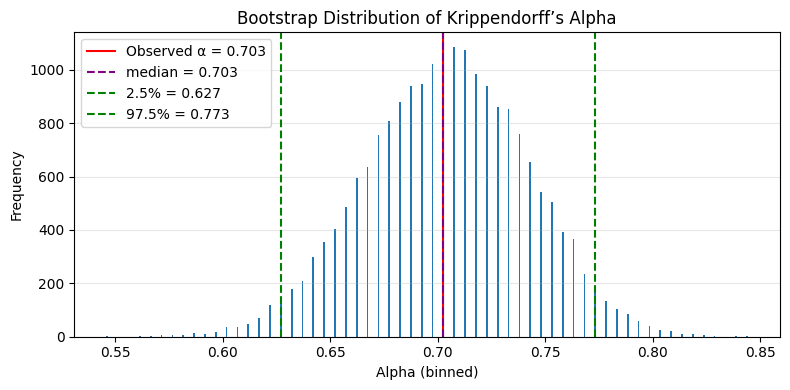

In [14]:
#plt.clf()
bin_labels = sorted([b for b in bins if b != '-1'])
bin_counts = [bins[b] for b in bin_labels]
                                                                                                                                                        
ci_low, ci_high = numpy.percentile(alphas, [2.5, 97.5])
median = numpy.median(alphas)

plt.figure(figsize=(8, 4))
plt.bar(bin_labels, bin_counts, width=0.0008)

plt.axvline(observed_alpha, color='red', linestyle='-', linewidth=1.5,
            label=f'Observed α = {observed_alpha:.3f}')
plt.axvline(median, linestyle='--', linewidth=1.5, color='purple', label=f'median = {median:.3f}')
plt.axvline(ci_low, linestyle='--', linewidth=1.5, color='green', label=f'2.5% = {ci_low:.3f}')
plt.axvline(ci_high, linestyle='--', linewidth=1.5, color='green', label=f'97.5% = {ci_high:.3f}')

plt.title("Bootstrap Distribution of Krippendorff’s Alpha")
plt.xlabel("Alpha (binned)")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()